# Synthetic dual-phase microstructures

In [1]:

# For creating DAMASK ready files
import damask
from damask import Grid
from damask import Rotation
from defdap.quat import Quat
from beta_reconstruction.crystal_relations import unq_cub_syms, burg_trans

# For generating arrays for VE
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage

from tqdm import tqdm


## Generating and visualising VE

In [19]:

# Functions for Generating VEs

def generate_polycrystalVE(n_seeds, grain_dimension_ratio, phase_indicies, phase_weights, grid, VE_size=[1,1,1]):
    """
    Generate polycrystal VE by voronoi tesselation with defined grain dimension ratio
    
    Parameters:
    n_grains: int: number of constituent grains or subgrains
    grain_dimension_ratio: list: ratio of grain dimesnions in 3D
    grid: tuple: number of material points in each axis
    VE_size: list: physical size of VE
    """
    matpoint_constituents = np.zeros(grid) # make 3d grid of zeros
    matpoint_phases = np.zeros(grid) # make 3d grid of zeros
    
    seeds = np.random.randint(grid[0], size=(n_seeds, 3)) # make array of random 3d coords
    distance = np.ones(grid) # make 3d grid of 1s
    print("Planting seeds...")
    for seed in tqdm(range(0, n_seeds)): # for each seed coord
        distance[seeds[seed,0], seeds[seed,1], seeds[seed,2]] = 0 # at seed coords, set distance=0
        # each seed assigned constituent idx, rest still zero
        matpoint_constituents[seeds[seed,0],seeds[seed,1],seeds[seed,2]] = seed
        
        # if multiphase, equal weights of probability const assigned phases
        # each seed assigned phase idx, rest still zero
        matpoint_phases[seeds[seed,0],seeds[seed,1],seeds[seed,2]] = np.random.choice(
            phase_indicies, 1, p=phase_weights)
        
    # vis_VE3D(microstructure, 0) # DEBUG - just seeds, no grains yet
    # Assign all points with const idx of nearest seed
    const_idx = ndimage.distance_transform_edt(distance, 
                                         return_distances=False, return_indices=True,
                                         sampling=1/np.array(grain_dimension_ratio))
    # Assign all points with phase idx of nearest seed
    phase_idx = ndimage.distance_transform_edt(distance, 
                                         return_distances=False, return_indices=True,
                                         sampling=1/np.array(grain_dimension_ratio))

    constituents = matpoint_constituents[const_idx[0], const_idx[1], const_idx[2]].astype(int) # VE of const idxs
    # reassign consts where seed didnt grow
    print(f"Re assigning const_idxs where seeds didnt take...")
    for c, const_idx in enumerate(np.sort(np.unique(constituents))):
        constituents[constituents==const_idx] = c
    
    phases = matpoint_phases[phase_idx[0], phase_idx[1], phase_idx[2]].astype(int) # VE of phase idxs
    # ====== Now got polycrystal microstructure ======== #
    print(f"GENERATED SYNTHETIC {constituents.shape} MICROSTRUCTURE:")
    print(f"Max constituent idx: {constituents.max()}")
    print(f"constituents indicies: {np.sort(np.unique(constituents))}")
    print(f"Actual number of unique constituents: {np.sort(np.unique(constituents)).shape}")
    print(f"Phase indicies: {np.sort(np.unique(phases))}")
    return constituents, phases


def generate_basicVE(phase_indicies, phase_weights, grid, VE_size=[1,1,1], subgrains=False):
    """
    Generate VE which all material points have different const idx
    """
    constituents = np.zeros(grid) # make 3d grid of zeros
    total_matpoints = np.prod(grid)
    print(f"Assigning constituents...")
    if subgrains==True:
        subgrain = 1
        for x in range(0, grid[0]):
            for y in range(0, grid[1]):
                for z in range(0, grid[2]):
                    constituents[x,y,z] = subgrain
                    subgrain +=1
    elif subgrains==False:
        pass
                
    print(f"Max constituent idx: {constituents.max()}")
    print(f"Total material points: {total_matpoints}")
    phases = np.random.choice(phase_indicies, size=grid, p=phase_weights)
    return constituents, phases


# Functions for creating and inserting ellipsoid
def ellipsoid_mask(array3d_shape, centre, radii):
    # Create a meshgrid
    grid = np.ogrid[[slice(-x, dim-x) for x, dim in zip(centre, array3d_shape)]]
    distances = np.sum((grid / radii)**2, axis=0, dtype=object)
    return distances <= 1

def insert_ellipsoid(constituents, phases, centre, radii, phase_idx, subgrains=False):
    """
    Insert single/polycrystal ellipsoid into 3D VE with defined axis dimensions
    microstructure: numpyarray: already defined microstructure
    centre: list: Position coords of centre of ellipsoid in microstructure grid
    subgrains: bool: split inside of ellipsoid up into grains or not
    """
    # Create a mask for the ellipsoid
    mask = ellipsoid_mask(phases.shape, np.array(centre), np.array(radii))
    # Set phase_idx specified
    phases[mask] = phase_idx
    # for consts half in and out ellipse, set phase idx to ellipse
    for const_idx in np.unique(constituents[mask]):
        phases[constituents==const_idx] = phase_idx
    print(f"Number of unique consts inside ellipsoid: {np.unique(constituents[mask]).shape}")
    return constituents, phases

def insert_cuboid(constituents, phases, centre, dims, phase_idx, subgrains=False):
    """
    Insert single/polycrystal cuboid into 3D VE with defined dimensions
    """
    phases[centre[0]:centre[0]+dims[0],
                   centre[1]:centre[1]+dims[1],
                   centre[2]:centre[2]+dims[2]] = phase_idx
    constituents[centre[0]:centre[0]+dims[0],
                 centre[1]:centre[1]+dims[1],
                 centre[2]:centre[2]+dims[2]] = constituents.max()+1
    return constituents, phases


def count_consts(microstructure, phase_idx):
    # unpack indicies
    constituents = microstructure[:,:,:,0]
    phases = microstructure[:,:,:,1]
    phase_consts = np.unique(constituents[phases==phase_idx]).shape[0]
    return phase_consts
    
def count_matpoints(microstructure, phase_idx):
    # unpack indicies
    constituents = microstructure[:,:,:,0]
    phases = microstructure[:,:,:,1]
    phase_matpoints = constituents[phases==phase_idx].shape[0]
    return phase_matpoints
    

In [3]:

# Define functions for visualisation

def vis_VE3D(array_3d, min_idx):
    """visualise one grain in microstructure on 3d plot
    value: microstructure val above which will be shown"""
    print(f"Visualising VE...")
    
    mask = array_3d>=min_idx
    
    x, y, z = np.indices(array_3d.shape)
    X, Y, Z = x[mask], y[mask], z[mask] # mask the arrays

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(X.flatten(), Y.flatten(), Z.flatten(),
                    c=array_3d[mask], marker='s')
    ax.set_xlim([0, array_3d.shape[0]])
    ax.set_ylim([0, array_3d.shape[1]])
    ax.set_zlim([0, array_3d.shape[2]])
    ax.set_xlabel('X')
    ax.invert_xaxis()
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.colorbar(sc)
    plt.show()


### Generate matrix

Planting seeds...


100%|██████████| 8000/8000 [00:00<00:00, 20453.07it/s]


Re assigning const_idxs where seeds didnt take...
GENERATED SYNTHETIC (32, 32, 32) MICROSTRUCTURE:
Max constituent idx: 7059
constituents indicies: [   0    1    2 ... 7057 7058 7059]
Actual number of unique constituents: (7060,)
Phase indicies: [0]
Visualising VE...


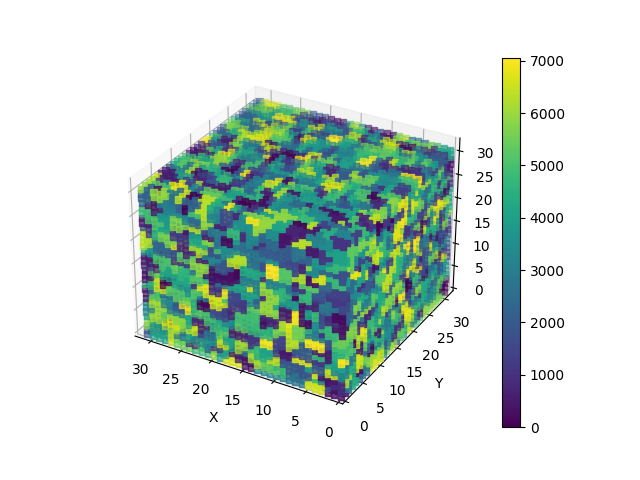

In [23]:

%matplotlib widget

n_seeds = 8000
phase_indicies=[0,1]
phase_weights=(1,0)
grid=(32,32,32)
VE_size=[1,1,1]

# every matpoint a constituent
# constituents, phases = generate_basicVE(phase_indicies, phase_weights, grid, VE_size, subgrains=True)

# 3D voronoi tesselation
constituents, phases = generate_polycrystalVE(n_seeds, grain_dimension_ratio=[1, 1, 1],
                                              phase_indicies = [0,1], phase_weights = (1,0),
                                              grid=grid, VE_size=VE_size)

# Visualise the voronoi 3D
vis_VE3D(constituents, min_idx=0) # "const_indx" or "phase_idx"


### Insert ellipsoid

In [27]:

# Insert ellipsoid into VE
constituents, phases = insert_ellipsoid(constituents, phases,
                                        centre=[16,16,8],
                                        radii=[10,10,2],
                                        phase_idx=1,
                                        subgrains=True)

# Insert cuboid into VE
# constituents, phases = insert_cuboid(constituents, phases,
#                                      centre=[0,0,0],
#                                      dims=(grid[0], grid[1], int(grid[2]/2)),
#                                      phase_idx=1, subgrains=True)


Number of unique consts inside ellipsoid: (265,)


/opt/gridware2/apps/binapps/anaconda3/2019.07/lib/python3.7/site-packages/ipykernel_launcher.py:82: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


Visualising VE...


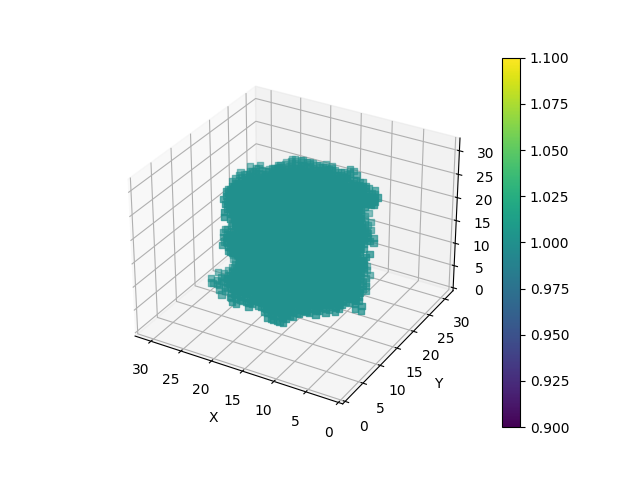

Constituents array shape: (32, 32, 32)
Phases array shape: (32, 32, 32)
Unique Beta constituents: (6261,)
Unique Alpha constituents: (799,)
Total unique constituents: (7060,) sum of a+b: 6261+799=7060
const_idxs: [   0    1    2 ... 7057 7058 7059]


In [29]:

# VE info
beta_constituents = constituents[phases==0]
alpha_constituents = constituents[phases==1]

# Visualise the shape(s) inserted
vis_VE3D(phases, min_idx=1) # "const_indx" or "phase_idx"

print(f"Constituents array shape: {constituents.shape}")
print(f"Phases array shape: {phases.shape}")
print(f"Unique Beta constituents: {np.sort(np.unique(beta_constituents)).shape}")
print(f"Unique Alpha constituents: {np.sort(np.unique(alpha_constituents)).shape}")
print(f"Total unique constituents: {np.sort(np.unique(constituents)).shape} sum of a+b: {np.unique(beta_constituents).shape[0]}+{np.unique(alpha_constituents).shape[0]}={np.unique(alpha_constituents).shape[0]+np.unique(beta_constituents).shape[0]}")
print(f"const_idxs: {np.unique(constituents)}")


## Generating orientations of phases

In [31]:

def random_unit_vector():
    """
    Generates a random 3D unit vector.
    """
    phi = np.random.uniform(0, 2*np.pi)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return np.array([x, y, z])

def random_quaternion():
    """
    Generates a random unit quaternion.
    """
    v = random_unit_vector()
    w = np.random.uniform(0, 2*np.pi)
    return np.array([np.cos(w/2), *np.sin(w/2) * v])

def alphabeta_BOR_euler(alpha_euler):
    phi1 = alpha_euler[0]*(np.pi/180)
    PHI = alpha_euler[1]*(np.pi/180)
    phi2 = alpha_euler[2]*(np.pi/180)
    alphaquat = Quat.fromEulerAngles(phi1, PHI, phi2)
    beta_eulers = []
    for sym in unq_cub_syms:
        BOR_betaquat = burg_trans.conjugate * sym * alphaquat
        BOR_beta_euler = Quat.eulerAngles(BOR_betaquat)*(180/np.pi)
        beta_eulers.append(BOR_beta_euler.astype(int))
    return beta_eulers
    

def pertubate_euler(ori, sigma=1):
    # Generate spread alpha and BOR spread beta
    # alpha euler (90,90,0)==basalTD, (0,90,0)==basalRD, (0,0,0)==basalND
    phi1 = ori[0]
    PHI = ori[1]
    phi2 = ori[2]
    # pertubate
    phi1_pert = phi1 + np.random.uniform(-sigma,sigma)
    PHI_pert = PHI + np.random.uniform(-sigma,sigma)
    phi2_pert = phi2 + np.random.uniform(-sigma,sigma)
    # convert to quat
    quat = Quat.fromEulerAngles(phi1_pert, PHI_pert, phi2_pert)
    return quat


def random_float_excluding(start, end, exclude=[]):
    while True:
        rand_float = np.random.uniform(start, end)
        if round(rand_float, 0) not in exclude:
            return rand_float
def perturbate_quat(quat, sigma):
    w1, x1, y1, z1 = quat[0], quat[1], quat[2], quat[3]
    # random choice of axis excluding zero
    axis = np.array([np.random.uniform(-1, 1),
                     np.random.uniform(-1, 1),
                     np.random.uniform(-1, 1)])
    # Normalize axis to get unit vector
    axis = axis / np.linalg.norm(axis)
    sin_half_angle = np.sin(sigma/2.0)
    # Create perturbation quat
    w2, x2, y2, z2 = np.array([np.cos(sigma/2.0), 
                               sin_half_angle * axis[0], 
                               sin_half_angle * axis[1], 
                               sin_half_angle * axis[2]])
    
    # Multiply the original quaternion by the perturbation quaternion
    return np.array([w1*w2 - x1*x2 - y1*y2 - z1*z2,
                     w1*x2 + x1*w2 + y1*z2 - z1*y2,
                     w1*y2 - x1*z2 + y1*w2 + z1*x2,
                     w1*z2 + x1*y2 - y1*x2 + z1*w2])
    

def BOR_beta(alpha_ori, sigma=1):
    """
    Generate a buncha perts around a BOR beta ori from central alpha ori
    """
    # For defined alpha ori, get BOR prior beta quat
    BOR_beta_quat = burg_trans.conjugate * unq_cub_syms[0] * alpha_ori  # from dafdap
    # pick first BOR beta, convert back to euler
    BOR_beta_euler = Quat.eulerAngles(BOR_beta_quat)
    # pertubate:
    beta_quat = pertubate_euler(BOR_beta_euler, sigma)
    return beta_quat


In [32]:

quaternions = np.ndarray(shape=(np.unique(constituents).shape[0], 4))
eulers = np.ndarray(shape=(np.unique(constituents).shape[0], 3))
phases = []

alpha_euler = np.array([30, 90, 0])*np.pi/180
alphaQuat = Quat.fromEulerAngles(alpha_euler[0],alpha_euler[1],alpha_euler[2])# takes radians as inputs

beta_euler = np.array([0, 45, 0])*np.pi/180

# Write oris to .txt to check textures with mtex
alpha_texture = open("alpha_texture.txt", 'w')
alpha_texture.write(f"w\tx\ty\tz\n")
beta_texture = open("beta_texture.txt", 'w')
beta_texture.write(f"w\tx\ty\tz\n")

n_alpha_oris = 0
n_beta_oris = 0
    
for const_idx in tqdm(np.unique(constituents)):
    if const_idx in beta_constituents: # if beta
        # beta_quat = BOR_beta(Quat.fromEulerAngles(alpha_euler[0],alpha_euler[1],alpha_euler[2]), sigma)
        eulers[const_idx] = beta_euler
        beta_quat = perturbate_quat(Quat.fromEulerAngles(beta_euler[0],beta_euler[1],beta_euler[2]), sigma=0.2)
        quaternions[const_idx] = beta_quat
        phases.append("Ti_beta")
        beta_texture.write(f"{beta_quat[0]}\t{beta_quat[1]}\t{beta_quat[2]}\t{beta_quat[3]}\n")
        n_beta_oris +=1
    elif const_idx in alpha_constituents:
        eulers[const_idx] = alpha_euler
        alpha_quat = perturbate_quat(alphaQuat, sigma=0.3)
        quaternions[const_idx] = alpha_quat
        phases.append("Ti_alpha")
        alpha_texture.write(f"{alpha_quat[0]}\t{alpha_quat[1]}\t{alpha_quat[2]}\t{alpha_quat[3]}\n")
        n_alpha_oris +=1
print(f"Written to file {np.unique(constituents).shape[0]} orientations")
print(f"Alpha oris: {n_alpha_oris}")
print(f"Beta oris: {n_beta_oris}")

alpha_texture.close()
beta_texture.close()


100%|██████████| 7060/7060 [00:00<00:00, 10802.44it/s]


Written to file 7060 orientations
Alpha oris: 799
Beta oris: 6261


## Create DAMASK geom and material files

In [33]:

# Save geom.vtr file
VE_name = f"alpha0002TD_beta110ND_{grid[0]}x.vtr"
g = Grid(constituents, VE_size) # g is now geometry file
g.save(fname=VE_name) # save g using new damask as .vtr

# save material.yaml file
material_yaml = open(f"alpha0002TD_beta110ND.yaml", 'w')
material_yaml.write(f"homogenization:\n\
  SX:\n\
    mechanical:\n\
      type: pass\n\
    N_constituents: 1\n\n\
phase:\n\
  Ti_alpha:\n\
    lattice: hP\n\
  Ti_beta:\n\
    lattice: cI\n\n\
material:\n")
for c in tqdm(range(0, np.unique(constituents).shape[0])):
    material_yaml.write(f"#grain {c}\n\
- homogenization: SX\n\
  constituents:\n\
  - v: 1.0\n\
    O:\n\
    - {quaternions[c][0]}\n\
    - {quaternions[c][1]}\n\
    - {quaternions[c][2]}\n\
    - {quaternions[c][3]}\n\
    phase: {phases[c]}\n\
    # eulers: {eulers[c]}")

material_yaml.close()


100%|██████████| 7060/7060 [00:00<00:00, 8462.98it/s]


## Add IPF of microstructure to the grid file
To check that orientations defined will be interpreted as desired by DAMASK
### - Sharan Roongta (s.roongta@mpie.de) and Philip Eisenlohr (eisenlohr@egr.msu.edu)
https://damask.mpie.de/documentation/examples/initial_IPF.html

In [19]:

v = damask.VTK.load(VE_name)
material_ID = v.get(label='material').flatten()
ma = damask.ConfigMaterial.load('material.yaml') # path for material.yaml


In [16]:

from tqdm import tqdm

phases = list(ma['phase'].keys())
info = []
for m in ma['material']:
    c = m['constituents'][0]
    phase = c['phase']
    info.append({'phaseID': phases.index(phase),
                 'lattice': ma['phase'][phase]['lattice'],
                 'O':       c['O'],
                })
# Add phaseIDs
pid = np.array([d['phaseID'] for d in info])
v.add(label='phaseID', data=pid[material_ID])

# Calculate and add IPF
lab_dirs = [np.array([0,0,1]), np.array([0,1,0]), np.array([1,0,0])] # lab frame direction for IPF
IPF = np.ones((len(material_ID),3),np.uint8)
for i, data in enumerate(tqdm(info)):
    for l in lab_dirs:
        IPF[np.where(material_ID==i)] = \
        np.uint8(damask.Orientation(data['O'],lattice=data['lattice']).IPF_color(l)*255)
        v.add(label=f'IPF_{l}', data=IPF)
    
v.save(f'{VE_name}')


IndexError: index 32768 is out of bounds for axis 0 with size 32768